In [42]:
!pip install -q -U keras-tuner

In [43]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from keras_tuner import RandomSearch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [44]:
# Load dan Preprocessing Data
def load_preprocess_data():
    (x_train, y_train), (x_test, y_test) = cifar10.load_data()
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0
    y_train = to_categorical(y_train, 10)
    y_test = to_categorical(y_test, 10)
    return (x_train, y_train), (x_test, y_test)

(x_train, y_train), (x_test, y_test) = load_preprocess_data()

In [45]:
# Augmentasi Data
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    shear_range=0.1,
)
datagen.fit(x_train)

In [46]:
# Definisikan Model dengan Hyperparameter Tuning
def build_model(hp):
    model = models.Sequential()

    # Input Layer
    model.add(layers.Input(shape=(32, 32, 3)))

    # Hyperparameter: Jumlah Conv Block (1-3)
    for i in range(hp.Int('num_conv_blocks', 1, 3)):
        # Hyperparameter: Jumlah Filter (32, 64, 128)
        filters = hp.Choice(f'filters_{i}', [32, 64, 128])
        # Hyperparameter: Ukuran Kernel (3x3 atau 5x5)
        kernel_size = hp.Choice(f'kernel_size_{i}', [3, 5])

        model.add(layers.Conv2D(filters, (kernel_size, kernel_size), padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))

        # Hyperparameter: Dropout Rate (0.1-0.5)
        dropout_rate = hp.Float(f'dropout_rate_conv_{i}', 0.1, 0.5, step=0.1)
        model.add(layers.Dropout(dropout_rate))

        # MaxPooling setiap Conv Block
        model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Flatten Layer
    model.add(layers.Flatten())

    # Hyperparameter: Dense Layers
    for j in range(hp.Int('num_dense_layers', 1, 2)):
        units = hp.Choice(f'units_dense_{j}', [128, 256, 512])
        model.add(layers.Dense(units))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))

        # Regularisasi L2 (opsional, contoh)
        # l2_rate = hp.Float(f'l2_rate_dense_{j}', 1e-5, 1e-3, sampling='log')
        # model.add(layers.Dense(units, kernel_regularizer=tf.keras.regularizers.l2(l2_rate)))

        dropout_rate = hp.Float(f'dropout_rate_dense_{j}', 0.2, 0.5, step=0.1)
        model.add(layers.Dropout(dropout_rate))

    # Output Layer
    model.add(layers.Dense(10, activation='softmax'))

    # Hyperparameter: Learning Rate
    learning_rate = hp.Choice('learning_rate', [1e-3, 1e-4])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [47]:
# Setup Hyperparameter Tuning
tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='cifar10_tuning',
    project_name='cnn_tuning_augmented'
)

# Tampilkan Ringkasan Pencarian
tuner.search_space_summary()

Search space summary
Default search space size: 8
num_conv_blocks (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
filters_0 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
kernel_size_0 (Choice)
{'default': 3, 'conditions': [], 'values': [3, 5], 'ordered': True}
dropout_rate_conv_0 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
num_dense_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 2, 'step': 1, 'sampling': 'linear'}
units_dense_0 (Choice)
{'default': 128, 'conditions': [], 'values': [128, 256, 512], 'ordered': True}
dropout_rate_dense_0 (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0001], 'ordered': True}


In [48]:
# Latih Model dengan Hyperparameter Tuning
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=3)
tuner.search(
    datagen.flow(x_train, y_train, batch_size=128),
    validation_data=(x_test, y_test),
    epochs=10,
    callbacks=[early_stop]
)

# Ambil Model Terbaik
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()

Trial 10 Complete [00h 05m 12s]
val_accuracy: 0.4672999978065491

Best val_accuracy So Far: 0.7506999969482422
Total elapsed time: 00h 47m 41s


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 649,290 (2.48 MB)

 Trainable params: 647,498 (2.47 MB)

 Non-trainable params: 1,792 (7.00 KB)


Test Accuracy: 0.7507, Test Loss: 0.7260
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.76      0.76      1000
           1       0.75      0.95      0.84      1000
           2       0.62      0.71      0.66      1000
           3       0.61      0.59      0.60      1000
           4       0.71      0.76      0.73      1000
           5       0.79      0.52      0.63      1000
           6       0.77      0.86      0.81      1000
           7       0.89      0.72      0.79      1000
           8       0.80      0.91      0.85      1000
           9       0.87      0.72      0.79      1000

    accuracy                           0.75     10000
   macro avg       0.76      0.75      0.75     10000
weighted avg       0.76      0.75      0.75     10000



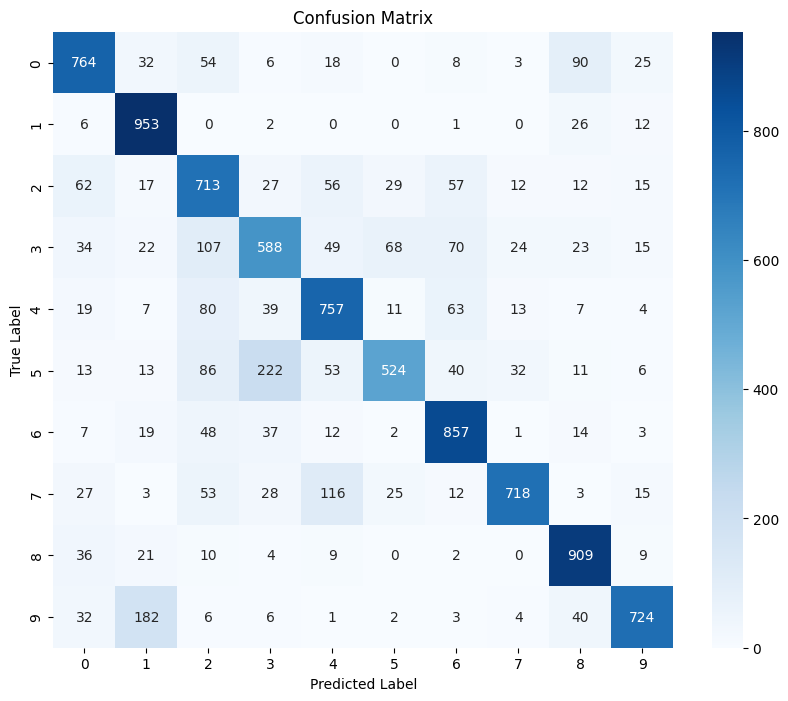

In [49]:
# Evaluasi Model Terbaik
test_loss, test_acc = best_model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

# Classification Report
y_pred = best_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)
print("\nClassification Report:\n", classification_report(y_true, y_pred_classes))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.7847 - loss: 0.6291 - val_accuracy: 0.7386 - val_loss: 0.7303
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8123 - loss: 0.5443 - val_accuracy: 0.6445 - val_loss: 1.0382
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8298 - loss: 0.4837 - val_accuracy: 0.5626 - val_loss: 1.4429
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8477 - loss: 0.4330 - val_accuracy: 0.7671 - val_loss: 0.6891
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8651 - loss: 0.3921 - val_accuracy: 0.7737 - val_loss: 0.6614
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8738 - loss: 0.3628 - val_accuracy: 0.7296 - val_loss: 0.8549
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8840 - loss: 0.3304 - val_accuracy: 0.7529 - val_loss: 0.7508
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9009 - loss: 0.2902 - val_

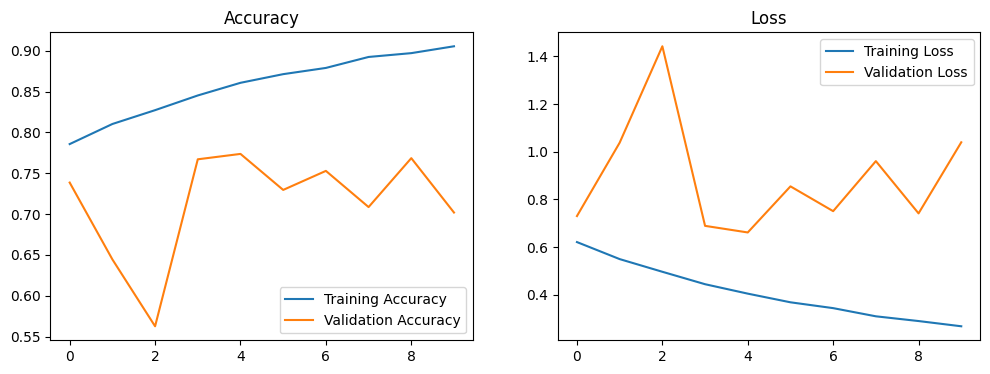

In [50]:

# Plot Akurasi dan Loss
history = best_model.fit(x_train, y_train,
                        validation_data=(x_test, y_test),
                        epochs=10,
                        batch_size=128)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [53]:
# Simpan Model Terbaik (Seluruh Model)
model_name = 'cifar10_best_model.keras'
best_model.save(model_name)
print("Model saved")

Model saved


In [ ]:
# Download Model dari Colab
# from google.colab import files
# files.download(model_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>